In [297]:
!pip install datasets

In [298]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.metrics import accuracy_score,f1_score


In [299]:
data=load_dataset('go_emotions')

In [300]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [301]:
data.shape


{'train': (43410, 3), 'validation': (5426, 3), 'test': (5427, 3)}

In [302]:
label_names=data['test'].features['labels'].feature.names

In [303]:
print(label_names)

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


DATA CLEANED

In [309]:
data.set_format(type='pandas')
df=data['train'][:]

In [310]:
label_names=data['train'].features['labels'].feature.names

In [311]:
df['classes']=df['labels'].apply(lambda x: label_names[x[0]] if len(x) > 0 else None)

In [312]:
df.drop(columns=['labels','id'],inplace=True)

In [371]:
df['text'][10]

'Demographics? I don’t know anybody under 35 who has cable tv.'

In [314]:
df['classes'].value_counts(normalize=True*100)

,proportion
classes,
neutral,0.295393
admiration,0.095139
approval,0.059802
amusement,0.051693
annoyance,0.049251
gratitude,0.048284
curiosity,0.040820
disapproval,0.038033
anger,0.035637


In [315]:
import matplotlib.pyplot as plt


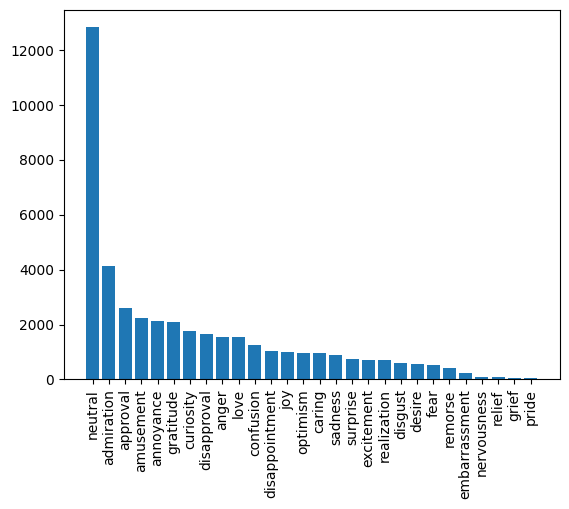

In [316]:
plt.bar(df['classes'].value_counts().index,df['classes'].value_counts().values)
plt.xticks(rotation=90)
plt.show()

In [317]:
df['Words']=df['text'].str.split().str.len()

In [318]:
df

,text,classes,Words
0,My favourite food is anything I didn't have to...,neutral,11
1,"Now if he does off himself, everyone will thin...",neutral,20
2,WHY THE FUCK IS BAYLESS ISOING,anger,6
3,To make her feel threatened,fear,5
4,Dirty Southern Wankers,annoyance,3
...,...,...,...
43405,Added you mate well I’ve just got the bow and ...,love,26
43406,Always thought that was funny but is it a refe...,confusion,12
43407,What are you talking about? Anything bad that ...,annoyance,19
43408,"More like a baptism, with sexy results!",excitement,7


In [319]:
print(df['text'][0])

My favourite food is anything I didn't have to cook myself.


In [320]:
import seaborn as sns

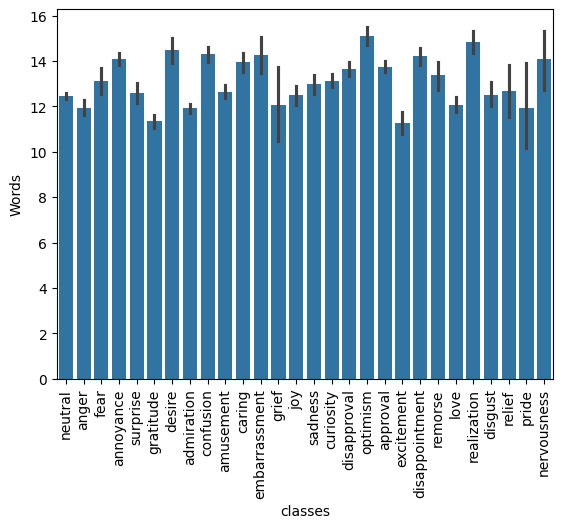

In [321]:
sns.barplot(y=df['Words'],x=df['classes'])
plt.xticks(rotation=90)
plt.show()

/tmp/ipython-input-487104902.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped_data, labels=labels)


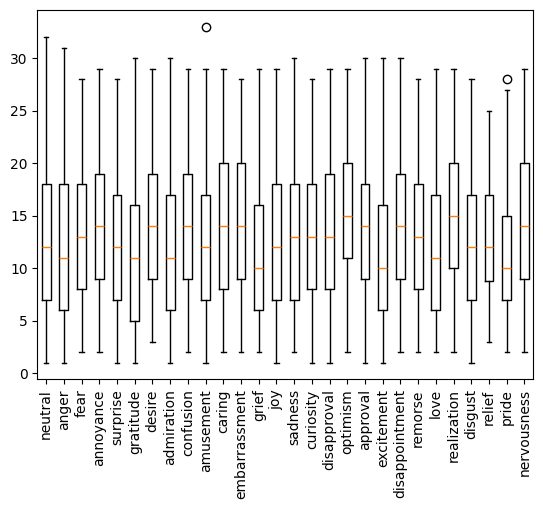

In [322]:
grouped_data = [df['Words'][df['classes'] == c] for c in df['classes'].unique()]
labels = df['classes'].unique()
plt.boxplot(grouped_data, labels=labels)
plt.xticks(rotation=90)
plt.show()

In [327]:
data.reset_format()
def convert_labels_to_single(example):

    if example['labels']:
        example['label'] = example['labels'][0]
    else:
        example['label'] = 0
    return example

data = data.map(convert_labels_to_single, batched=False)
data = data.remove_columns(["labels", "id"])

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Tokenization

In [328]:
from transformers import AutoTokenizer

In [329]:
modelc='distilbert/distilbert-base-uncased'
tokenizer=AutoTokenizer.from_pretrained(modelc)

In [331]:
tokens=tokenizer.convert_ids_to_tokens(encoded_txt['input_ids'])

In [332]:
tokens

['[CLS]', 'i', 'love', 'computers', 'and', 'sports', '!', '.', '[SEP]']

In [333]:
tokenizer.vocab_size,tokenizer.model_max_length

(30522, 512)

In [335]:
def tokenize(batch):
  return tokenizer(list(batch['text']),padding=True,truncation=True)


In [336]:
print(tokenize(data['train'][:2]))#attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1] 0 mean padded words ,model ignore it

{'input_ids': [[101, 2026, 8837, 2833, 2003, 2505, 1045, 2134, 1005, 1056, 2031, 2000, 5660, 2870, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2085, 2065, 2002, 2515, 2125, 2370, 1010, 3071, 2097, 2228, 2002, 2015, 2383, 1037, 4756, 29082, 2007, 2111, 2612, 1997, 2941, 2757, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [337]:
data_tokenized=data.map(tokenize,batched=True,batch_size=None)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [338]:
data_tokenized

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 5427
    })
})

Model

In [339]:
from transformers import AutoModel
import torch

In [340]:
model=AutoModel.from_pretrained(modelc)

In [341]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [342]:
#Embedding

In [343]:
with torch.no_grad():
  out=model(**input)

In [344]:
last_hidden_state=out.last_hidden_state

In [345]:
out


BaseModelOutput(last_hidden_state=tensor([[[ 0.1064,  0.0471,  0.0056,  ..., -0.1032,  0.4452,  0.2823],
         [ 0.5847,  0.1463, -0.0695,  ..., -0.0379,  0.6028,  0.3195],
         [ 0.7712,  0.7318,  0.6357,  ..., -0.1791,  0.2976, -0.1228],
         ...,
         [ 0.4881,  0.0566,  0.3401,  ...,  0.2594,  0.3520, -0.2326],
         [ 0.1348, -0.6357,  0.2214,  ...,  0.3396,  0.1397, -0.5342],
         [ 0.9385,  0.2512, -0.3397,  ...,  0.1096, -0.4346, -0.3060]]]), hidden_states=None, attentions=None)

In [346]:
last_hidden_state

tensor([[[ 0.1064,  0.0471,  0.0056,  ..., -0.1032,  0.4452,  0.2823],
         [ 0.5847,  0.1463, -0.0695,  ..., -0.0379,  0.6028,  0.3195],
         [ 0.7712,  0.7318,  0.6357,  ..., -0.1791,  0.2976, -0.1228],
         ...,
         [ 0.4881,  0.0566,  0.3401,  ...,  0.2594,  0.3520, -0.2326],
         [ 0.1348, -0.6357,  0.2214,  ...,  0.3396,  0.1397, -0.5342],
         [ 0.9385,  0.2512, -0.3397,  ...,  0.1096, -0.4346, -0.3060]]])

In [347]:
last_hidden_state.shape

torch.Size([1, 9, 768])

Prediction

Tokenization->Token->Embedding->Classification head->pred

In [348]:
#bert for understand and predic next word(mark)  not for classifiaction
#Fine Tune

In [349]:
from transformers import AutoModelForSequenceClassification

In [350]:
num_labels=28
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=AutoModelForSequenceClassification.from_pretrained(modelc,num_labels=num_labels).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [351]:
device

device(type='cuda')

In [352]:
from transformers import TrainingArguments

In [353]:
batch_size = 32
model_name = 'finetune-distilbert'

trainingarg = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    disable_tqdm=False,
    report_to=[]  # <-- disables wandb and any other logger
)


In [354]:
def compute(pred):
  labels=pred.label_ids
  preds=pred.predictions.argmax(-1)
  f1=f1_score(labels,preds,average='weighted')
  acc=accuracy_score(labels,preds)
  return {'accuracy':acc,'f1':f1}

In [355]:
from transformers import Trainer

In [356]:
trainer = Trainer(
    model=model,
    args=trainingarg,
    compute_metrics=compute,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['validation'],
    tokenizer=tokenizer,

)


/tmp/ipython-input-2074768219.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [357]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.657500,1.470357,0.569296,0.540911


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.657500,1.470357,0.569296,0.540911
2,1.362100,1.400879,0.585146,0.560775


TrainOutput(global_step=2714, training_loss=1.606701529720028, metrics={'train_runtime': 2254.9783, 'train_samples_per_second': 38.501, 'train_steps_per_second': 1.204, 'total_flos': 7101453293562240.0, 'train_loss': 1.606701529720028, 'epoch': 2.0})

In [358]:
preds_outputs = trainer.predict(data_tokenized['test'])
preds_outputs.metrics


{'test_loss': 1.4228953123092651,
 'test_accuracy': 0.5774829555924084,
 'test_f1': 0.5533494811050212,
 'test_runtime': 9.2993,
 'test_samples_per_second': 583.595,
 'test_steps_per_second': 18.281}

In [360]:
import numpy as np
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = data_tokenized['test'][:]['label']


from sklearn.metrics import classification_report
print(classification_report(y_true, y_preds))


              precision    recall  f1-score   support

           0       0.65      0.75      0.70       504
           1       0.74      0.88      0.81       252
           2       0.48      0.50      0.49       197
           3       0.33      0.19      0.24       286
           4       0.52      0.33      0.40       318
           5       0.44      0.32      0.37       114
           6       0.50      0.36      0.42       139
           7       0.43      0.61      0.51       233
           8       0.62      0.39      0.48        74
           9       0.38      0.19      0.25       127
          10       0.44      0.37      0.40       220
          11       0.46      0.38      0.42        84
          12       1.00      0.03      0.06        30
          13       0.50      0.31      0.38        84
          14       0.63      0.64      0.63        74
          15       0.83      0.84      0.84       288
          16       0.00      0.00      0.00         6
          17       0.52    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [376]:
def predict(text):
     input_encoded = tokenizer(text, return_tensors='pt').to(device)
     with torch.no_grad():
         outputs = model(**input_encoded)

     logits = outputs.logits
     pred = torch.argmax(logits, dim=1).item()
     return pred, label_names[pred]

In [377]:
text = 'I cant wait for tomorrow, Im so excited!'
predict(text)

(13, 'excitement')

In [378]:
text2="Wow! I didnt expect that to happen at all!"
predict(text2)

(26, 'surprise')

In [379]:
text3="I’m trying so hard, but it feels like nothing will ever change no matter what I do."
predict(text3)

(25, 'sadness')

In [381]:
text4="Oh wow, another failure — just what I needed to make my day even better."
predict(text4)

(9, 'disappointment')

In [363]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.9873, -1.4477,  3.0827,  1.4712, -0.5059, -0.4280, -0.8745,  0.0791,
          1.1784, -0.5042, -0.6418,  0.1699, -1.1088, -1.1055,  0.4422, -2.2402,
         -1.9381, -1.5613, -0.3928, -1.1462, -0.6646, -2.5870, -1.1759, -1.9150,
         -1.1851, -0.5161, -1.7918,  1.7413]], device='cuda:0'), hidden_states=None, attentions=None)